# AI-Powered Operational Excellence & Agentic Workflow Automation
## Pharmaceuticals - Northeastern University
### February 2026

**Project Overview:**
- End-to-end AI pipeline processing 15K+ operational records
- Lean Six Sigma methodologies integrated with AI agents
- Automated Pareto analysis and root-cause identification
- Real-time Power BI dashboard with GenAI summarization
- AI governance protocols and performance tracking

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_generator import generate_operational_data
from lean_six_sigma import LeanSixSigmaAnalyzer
from ai_agent import AIAnalysisAgent

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Environment initialized successfully")

Environment initialized successfully


## 1. Data Generation & Loading
Simulating 15,000+ pharmaceutical operational records with realistic patterns

In [2]:
df = generate_operational_data(15000)
df.to_csv('../data/vertex_operations.csv', index=False)

print(f"Dataset Shape: {df.shape}")
print(f"\nDate Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nProcess Steps: {df['process_step'].nunique()}")
print(f"Sites: {df['site_location'].nunique()}")
print(f"Product Lines: {df['product_line'].nunique()}")

df.head()

Dataset Shape: (15000, 17)

Date Range: 2024-01-01 00:00:00 to 2025-09-16 23:00:00

Process Steps: 7
Sites: 3
Product Lines: 4


,record_id,timestamp,process_step,site_location,product_line,batch_id,cycle_time_minutes,defect_count,resource_utilization,wait_time_minutes,temperature_celsius,humidity_percent,operator_id,equipment_id,yield_percent,rework_required,cost_usd
0,1,2024-01-01 00:00:00,Distribution,Site C - California,Cardiovascular,BATCH-7711,56.700032,3,0.894105,1.854344,23.011515,39.924149,OP-896,EQ-049,83.589392,0,1571.883612
1,2,2024-01-01 01:00:00,Packaging,Site B - New Jersey,Neurology,BATCH-2918,90.929908,2,0.846337,14.906763,21.312292,43.417955,OP-920,EQ-008,94.293377,0,470.701991
2,3,2024-01-01 02:00:00,Quality Control,Site B - New Jersey,Oncology,BATCH-9166,187.119572,7,0.918071,1.044877,19.694129,38.867066,OP-836,EQ-008,90.429374,0,1764.274624
3,4,2024-01-01 03:00:00,Distribution,Site C - California,Immunology,BATCH-7025,53.397025,2,0.902675,28.169941,20.763664,39.779033,OP-163,EQ-011,92.269431,0,11043.981068
4,5,2024-01-01 04:00:00,Filling,Site B - New Jersey,Neurology,BATCH-7099,398.451118,2,0.812555,6.938285,23.248634,47.394340,OP-369,EQ-009,92.811967,0,5621.429419


In [3]:
# Statistical summary
df.describe()

,record_id,timestamp,cycle_time_minutes,defect_count,resource_utilization,wait_time_minutes,temperature_celsius,humidity_percent,yield_percent,rework_required,cost_usd
count,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,2024-11-08 11:30:00,104.512023,2.775733,0.747713,33.423331,21.998559,45.033381,93.870221,0.126533,10240.006471
min,1.000000,2024-01-01 00:00:00,7.105586,0.000000,0.300000,0.001422,14.001336,27.182033,79.275841,0.000000,37.327383
25%,3750.750000,2024-06-05 05:45:00,50.775698,1.000000,0.651121,8.766556,20.661098,41.642842,91.269370,0.000000,2214.255098
50%,7500.500000,2024-11-08 11:30:00,79.272490,2.000000,0.749665,21.159729,22.010739,44.987344,93.987116,0.000000,5006.198125
75%,11250.250000,2025-04-13 17:15:00,126.701455,4.000000,0.850649,44.663714,23.304695,48.443277,96.662981,0.000000,11325.672964
max,15000.000000,2025-09-16 23:00:00,2325.143241,16.000000,1.000000,362.458608,29.532467,63.539526,100.000000,1.000000,393280.198841
std,4330.271354,NaN,95.592308,2.123112,0.143328,37.794935,2.000130,5.013628,3.747313,0.332461,16937.051232


### Data Quality Assessment

In [4]:
# Check for missing values
missing_data = df.isnull().sum()
print("Missing Values:")
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "No missing values")

# Data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
No missing values

Data Types:
record_id                        int64
timestamp               datetime64[us]
process_step                       str
site_location                      str
product_line                       str
batch_id                           str
cycle_time_minutes             float64
defect_count                     int64
resource_utilization           float64
wait_time_minutes              float64
temperature_celsius            float64
humidity_percent               float64
operator_id                        str
equipment_id                       str
yield_percent                  float64
rework_required                  int64
cost_usd                       float64
dtype: object


### Visualization 1: Distribution of Key Metrics

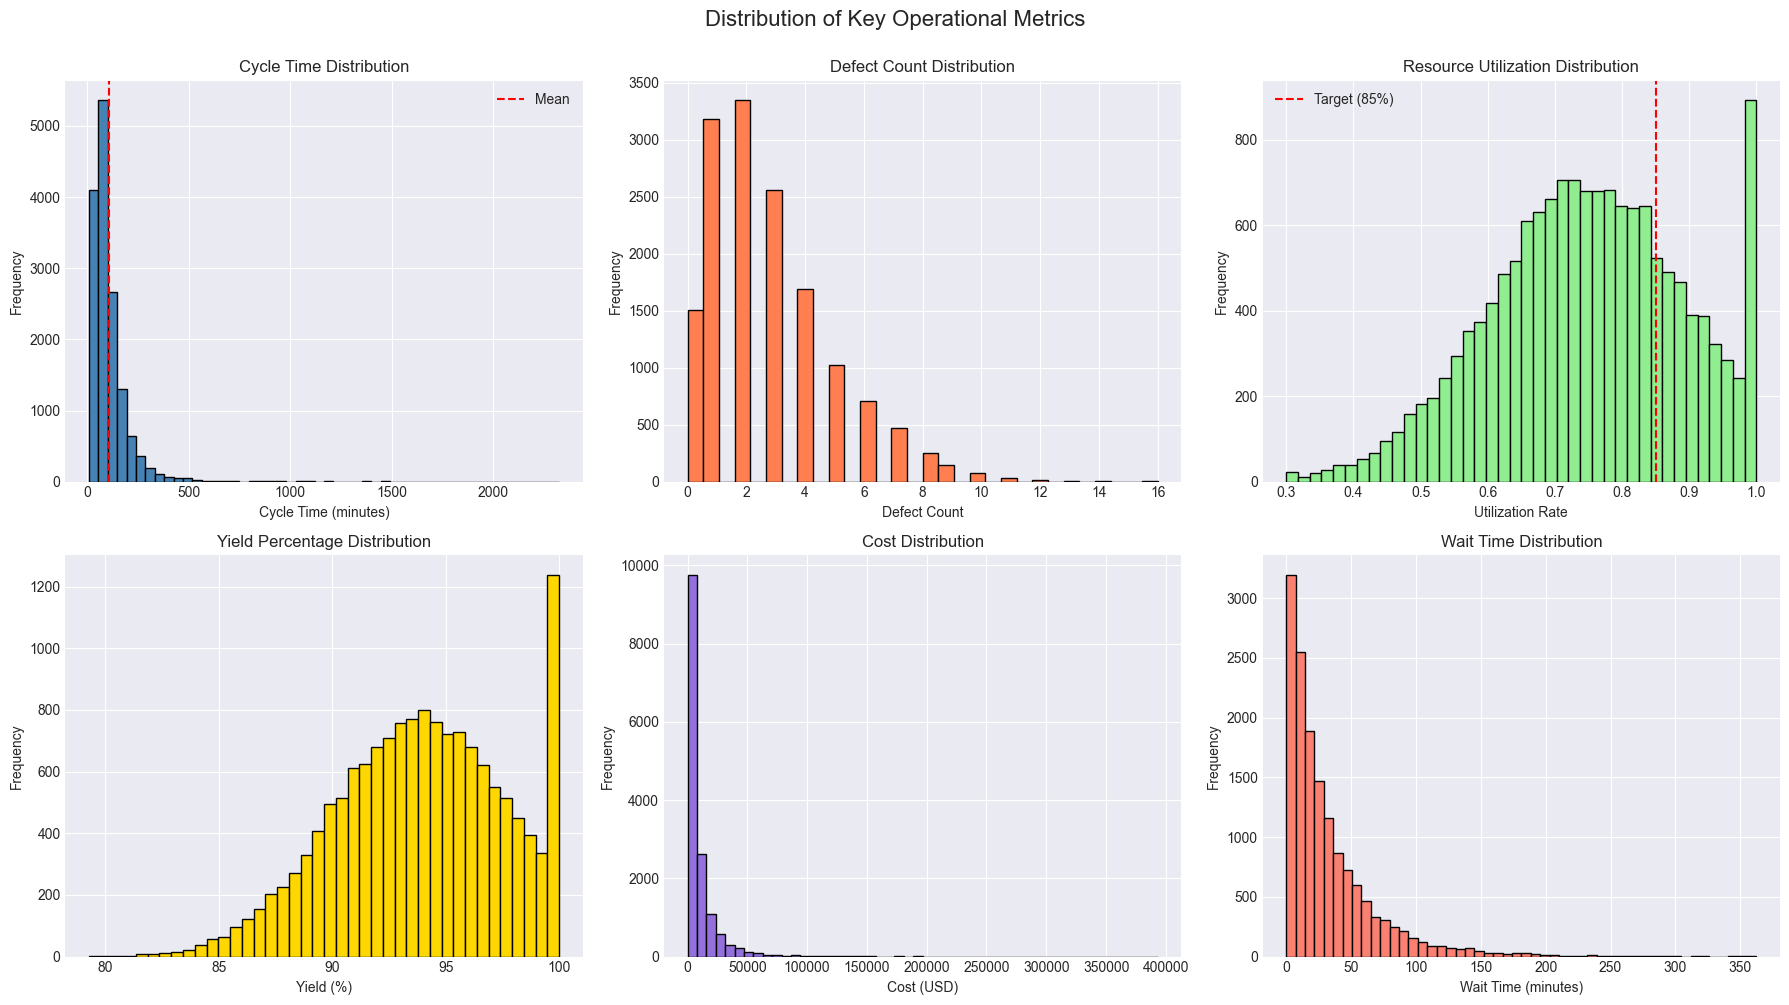

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Key Operational Metrics', fontsize=16, y=1.00)

# Cycle Time Distribution
axes[0, 0].hist(df['cycle_time_minutes'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Cycle Time Distribution')
axes[0, 0].set_xlabel('Cycle Time (minutes)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['cycle_time_minutes'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# Defect Count Distribution
axes[0, 1].hist(df['defect_count'], bins=30, color='coral', edgecolor='black')
axes[0, 1].set_title('Defect Count Distribution')
axes[0, 1].set_xlabel('Defect Count')
axes[0, 1].set_ylabel('Frequency')

# Resource Utilization
axes[0, 2].hist(df['resource_utilization'], bins=40, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Resource Utilization Distribution')
axes[0, 2].set_xlabel('Utilization Rate')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(0.85, color='red', linestyle='--', label='Target (85%)')
axes[0, 2].legend()

# Yield Percentage
axes[1, 0].hist(df['yield_percent'], bins=40, color='gold', edgecolor='black')
axes[1, 0].set_title('Yield Percentage Distribution')
axes[1, 0].set_xlabel('Yield (%)')
axes[1, 0].set_ylabel('Frequency')

# Cost Distribution
axes[1, 1].hist(df['cost_usd'], bins=50, color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('Cost Distribution')
axes[1, 1].set_xlabel('Cost (USD)')
axes[1, 1].set_ylabel('Frequency')

# Wait Time Distribution
axes[1, 2].hist(df['wait_time_minutes'], bins=50, color='salmon', edgecolor='black')
axes[1, 2].set_title('Wait Time Distribution')
axes[1, 2].set_xlabel('Wait Time (minutes)')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/metric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualization 2: Process Step Analysis

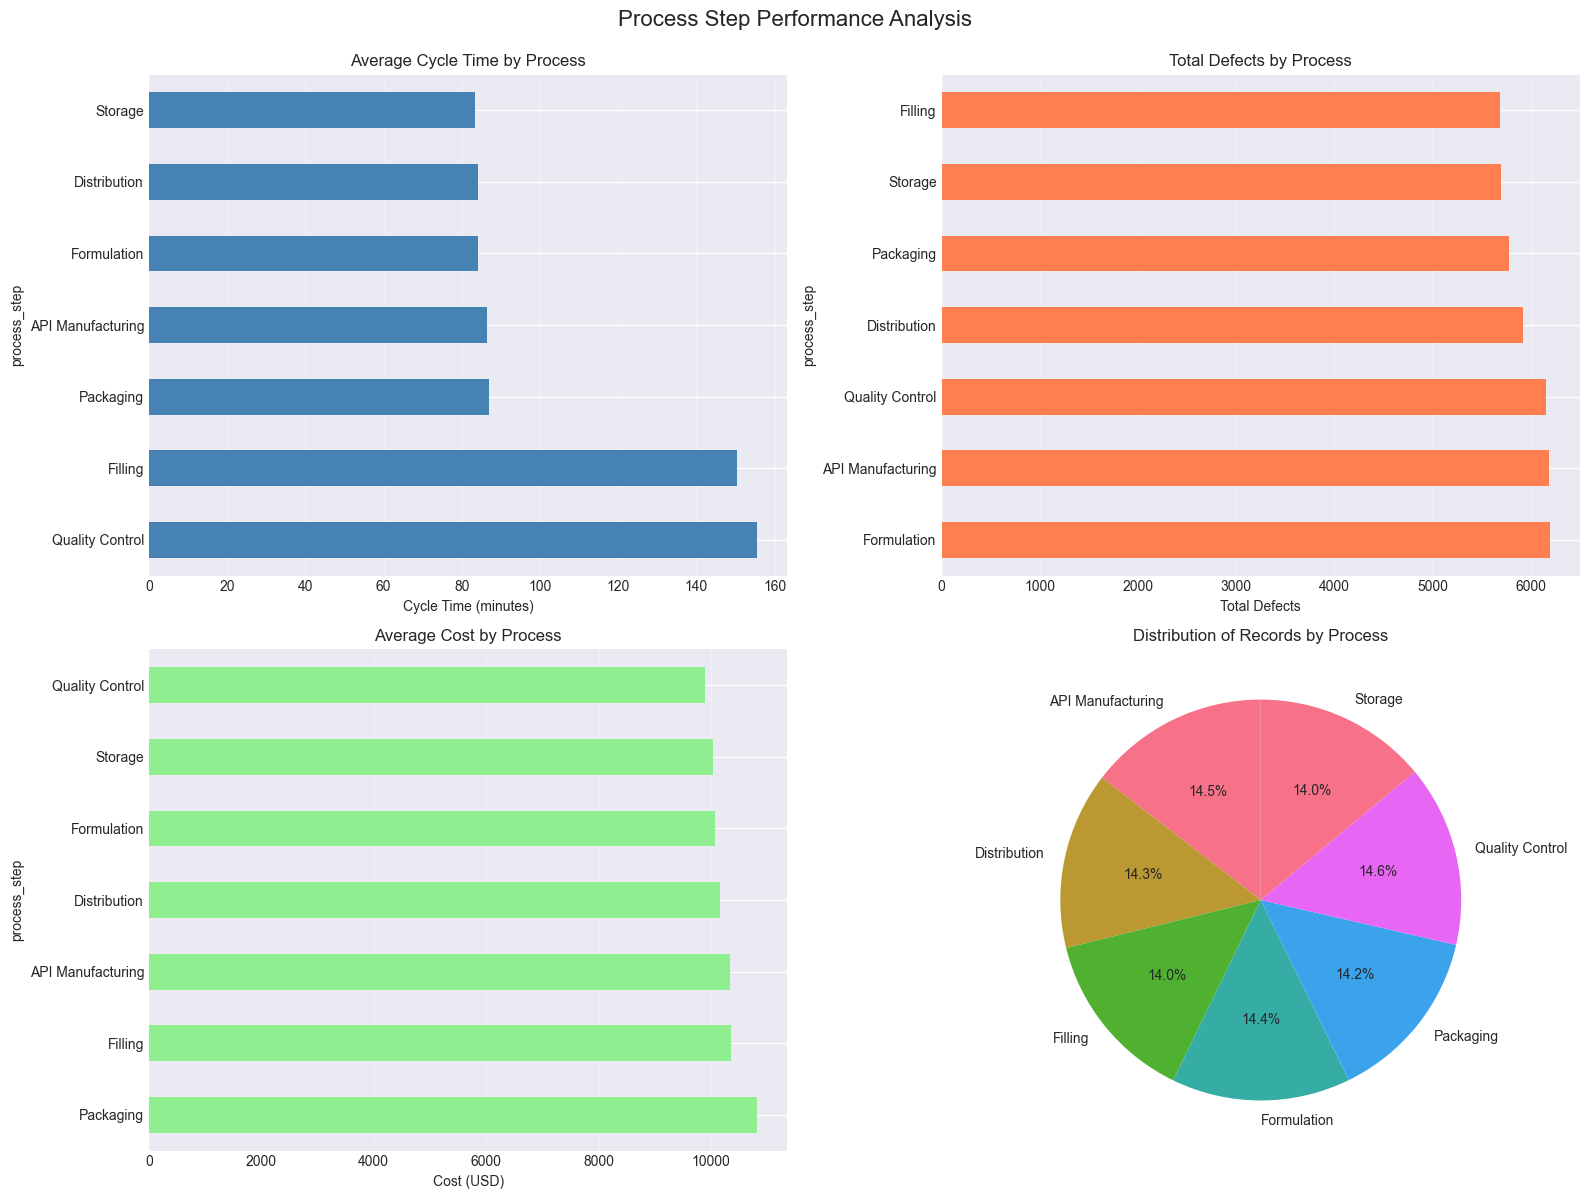


Process Metrics Summary:
                   Avg Cycle Time  Total Defects  Avg Cost  Count
process_step                                                     
API Manufacturing           86.55           6186  10345.47   2180
Distribution                84.10           5926  10162.10   2147
Filling                    150.49           5692  10350.69   2093
Formulation                 84.12           6193  10079.63   2166
Packaging                   87.06           5782  10819.40   2125
Quality Control            155.51           6156   9901.76   2196
Storage                     83.49           5701  10032.01   2093


In [6]:
# Process step metrics
process_metrics = df.groupby('process_step').agg({
    'cycle_time_minutes': 'mean',
    'defect_count': 'sum',
    'cost_usd': 'mean',
    'record_id': 'count'
}).round(2)
process_metrics.columns = ['Avg Cycle Time', 'Total Defects', 'Avg Cost', 'Count']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Process Step Performance Analysis', fontsize=16, y=0.995)

# Average Cycle Time by Process
process_metrics['Avg Cycle Time'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[0, 0], color='steelblue'
)
axes[0, 0].set_title('Average Cycle Time by Process')
axes[0, 0].set_xlabel('Cycle Time (minutes)')
axes[0, 0].grid(axis='x', alpha=0.3)

# Total Defects by Process
process_metrics['Total Defects'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[0, 1], color='coral'
)
axes[0, 1].set_title('Total Defects by Process')
axes[0, 1].set_xlabel('Total Defects')
axes[0, 1].grid(axis='x', alpha=0.3)

# Average Cost by Process
process_metrics['Avg Cost'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[1, 0], color='lightgreen'
)
axes[1, 0].set_title('Average Cost by Process')
axes[1, 0].set_xlabel('Cost (USD)')
axes[1, 0].grid(axis='x', alpha=0.3)

# Record Count by Process
process_metrics['Count'].plot(
    kind='pie', ax=axes[1, 1], autopct='%1.1f%%', startangle=90
)
axes[1, 1].set_title('Distribution of Records by Process')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.savefig('../outputs/process_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nProcess Metrics Summary:")
print(process_metrics)

### Visualization 3: Site Performance Comparison

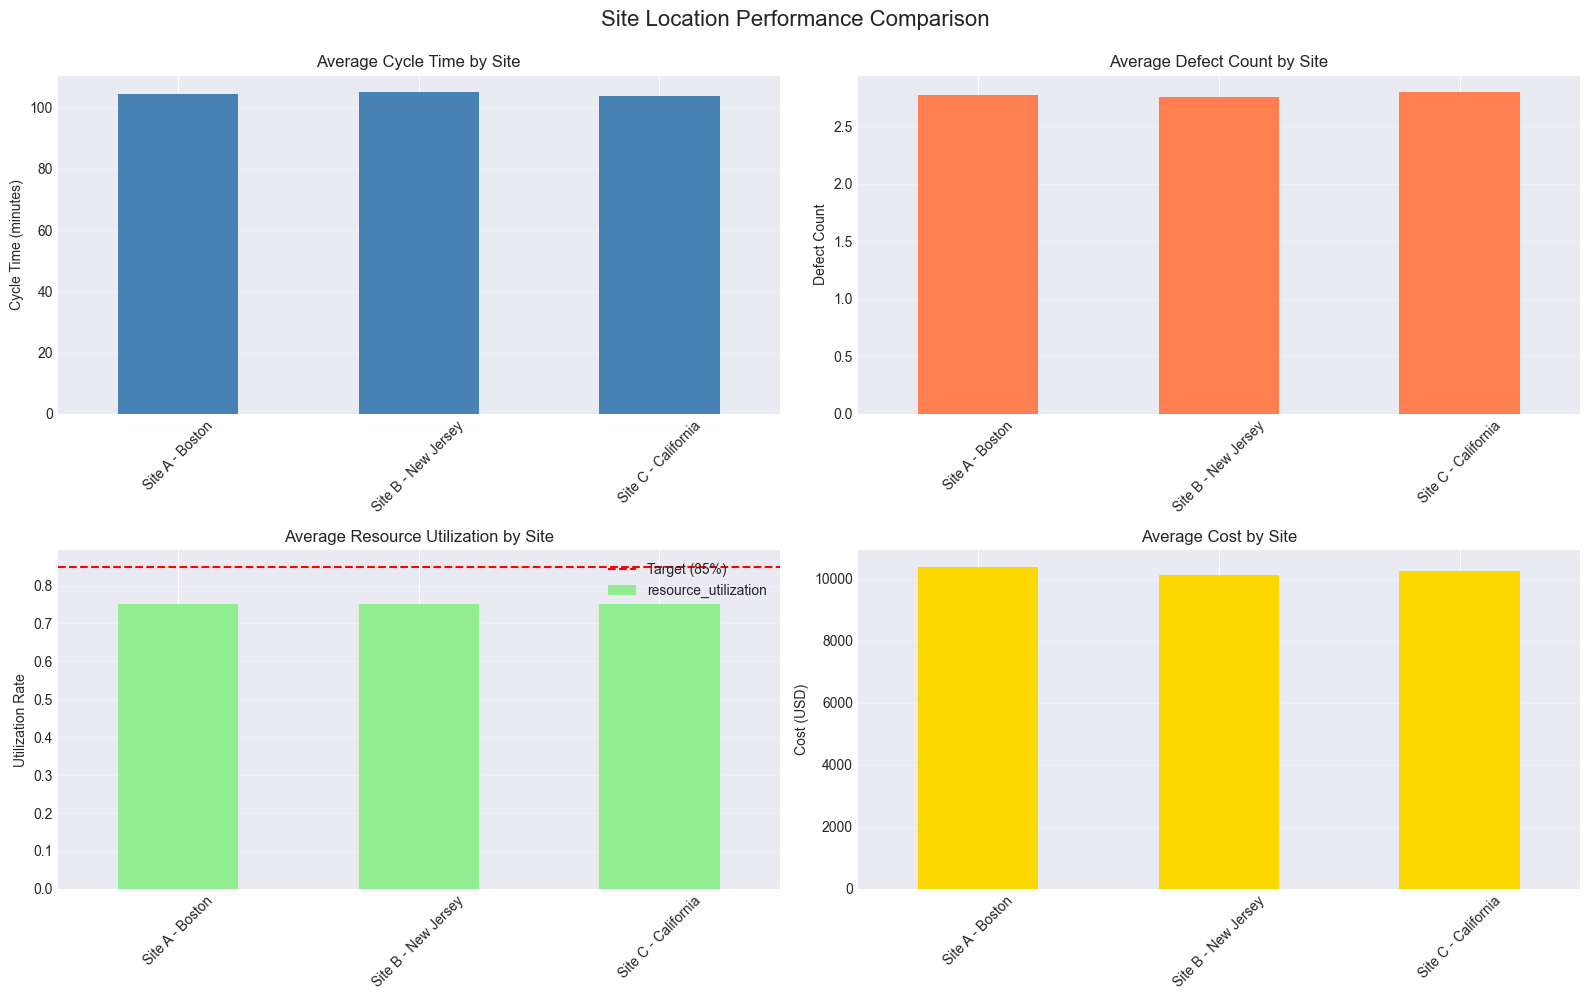


Site Metrics Summary:
                     cycle_time_minutes  defect_count  resource_utilization  \
site_location                                                                 
Site A - Boston                  104.57          2.77                  0.75   
Site B - New Jersey              105.24          2.75                  0.75   
Site C - California              103.71          2.80                  0.75   

                     cost_usd  
site_location                  
Site A - Boston      10385.12  
Site B - New Jersey  10104.72  
Site C - California  10232.92  


In [7]:
site_metrics = df.groupby('site_location').agg({
    'cycle_time_minutes': 'mean',
    'defect_count': 'mean',
    'resource_utilization': 'mean',
    'cost_usd': 'mean'
}).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Site Location Performance Comparison', fontsize=16, y=0.995)

# Cycle Time by Site
site_metrics['cycle_time_minutes'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Average Cycle Time by Site')
axes[0, 0].set_ylabel('Cycle Time (minutes)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Defect Count by Site
site_metrics['defect_count'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Average Defect Count by Site')
axes[0, 1].set_ylabel('Defect Count')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Resource Utilization by Site
site_metrics['resource_utilization'].plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Average Resource Utilization by Site')
axes[1, 0].set_ylabel('Utilization Rate')
axes[1, 0].set_xlabel('')
axes[1, 0].axhline(y=0.85, color='red', linestyle='--', label='Target (85%)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Cost by Site
site_metrics['cost_usd'].plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Average Cost by Site')
axes[1, 1].set_ylabel('Cost (USD)')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/site_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSite Metrics Summary:")
print(site_metrics)

## 2. Lean Six Sigma Analysis
### DMAIC Methodology Implementation

In [8]:
lss = LeanSixSigmaAnalyzer(df)

dpmo_results = lss.calculate_dpmo()
print("="*50)
print("DEFECTS PER MILLION OPPORTUNITIES (DPMO)")
print("="*50)
print(f"DPMO: {dpmo_results['DPMO']:,.2f}")
print(f"Sigma Level: {dpmo_results['Sigma_Level']:.1f} sigma")
print(f"\nTarget: 3.4 DPMO (6 sigma)")
print(f"Current Performance: {'Below' if dpmo_results['DPMO'] > 3.4 else 'Above'} World-Class")

DEFECTS PER MILLION OPPORTUNITIES (DPMO)
DPMO: 2,775,733.33
Sigma Level: 2.0 sigma

Target: 3.4 DPMO (6 sigma)
Current Performance: Below World-Class


In [9]:
capability = lss.process_capability_analysis()
print("="*50)
print("PROCESS CAPABILITY ANALYSIS")
print("="*50)
print(f"Cp (Process Capability): {capability['Cp']:.3f}")
print(f"Cpk (Process Capability Index): {capability['Cpk']:.3f}")
print(f"\nInterpretation:")
if capability['Cpk'] >= 1.33:
    print("Process is CAPABLE (Cpk >= 1.33)")
elif capability['Cpk'] >= 1.0:
    print("Process is MARGINALLY capable (1.0 <= Cpk < 1.33)")
else:
    print("Process is NOT capable (Cpk < 1.0)")

PROCESS CAPABILITY ANALYSIS
Cp (Process Capability): 0.445
Cpk (Process Capability Index): 0.344

Interpretation:
Process is NOT capable (Cpk < 1.0)


### Visualization 4: Process Capability Chart

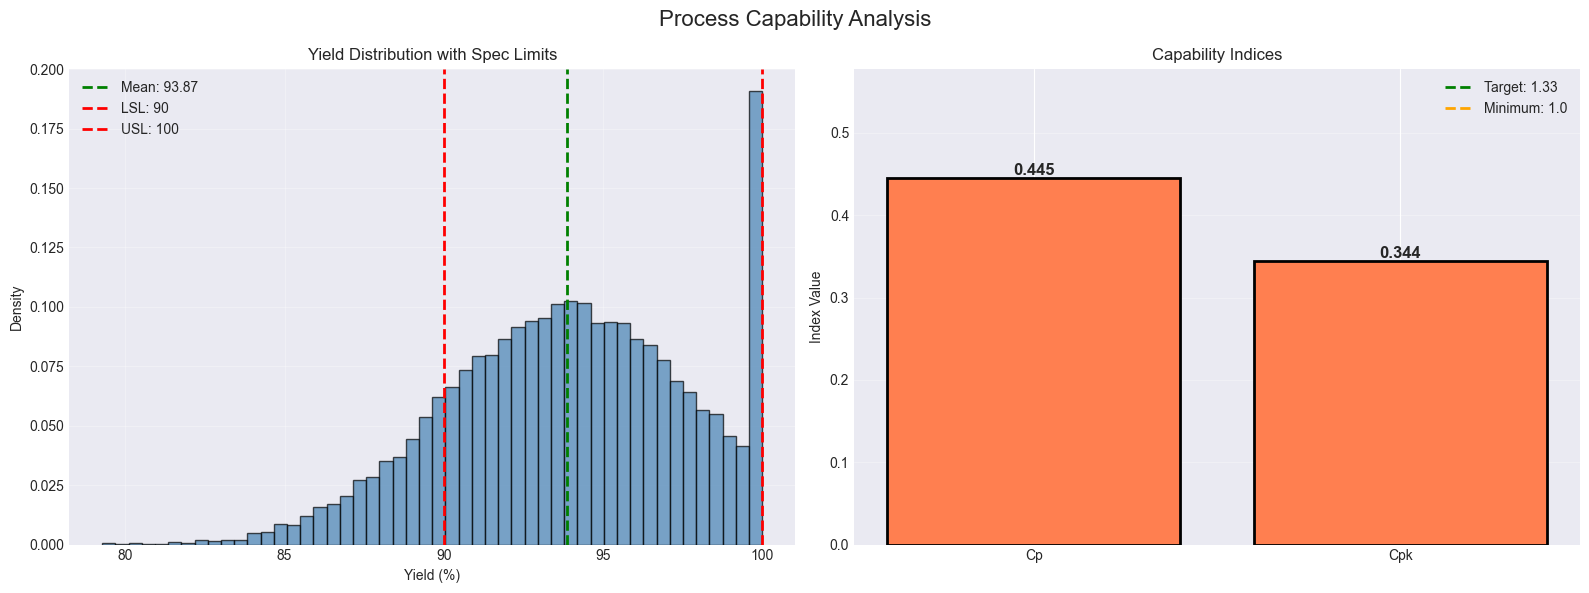

In [10]:
# Process Capability Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Process Capability Analysis', fontsize=16)

# Histogram with specification limits
data = df['yield_percent'].dropna()
axes[0].hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(data.mean(), color='green', linestyle='--', linewidth=2, label=f"Mean: {data.mean():.2f}")
axes[0].axvline(90, color='red', linestyle='--', linewidth=2, label='LSL: 90')
axes[0].axvline(100, color='red', linestyle='--', linewidth=2, label='USL: 100')
axes[0].set_title('Yield Distribution with Spec Limits')
axes[0].set_xlabel('Yield (%)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cp and Cpk comparison
capability_metrics = ['Cp', 'Cpk']
capability_values = [capability['Cp'], capability['Cpk']]
colors = ['lightgreen' if v >= 1.33 else 'coral' for v in capability_values]

bars = axes[1].bar(capability_metrics, capability_values, color=colors, edgecolor='black', linewidth=2)
axes[1].axhline(y=1.33, color='green', linestyle='--', linewidth=2, label='Target: 1.33')
axes[1].axhline(y=1.0, color='orange', linestyle='--', linewidth=2, label='Minimum: 1.0')
axes[1].set_title('Capability Indices')
axes[1].set_ylabel('Index Value')
axes[1].set_ylim(0, max(capability_values) * 1.3)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, capability_values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/process_capability.png', dpi=300, bbox_inches='tight')
plt.show()

### Process Bottleneck Identification

In [11]:
bottlenecks = lss.identify_bottlenecks(threshold_multiplier=1.5)
print("="*50)
print("PROCESS BOTTLENECKS IDENTIFIED")
print("="*50)
if len(bottlenecks) > 0:
    print(bottlenecks)
else:
    print("No significant bottlenecks detected at 1.5x threshold")

PROCESS BOTTLENECKS IDENTIFIED
No significant bottlenecks detected at 1.5x threshold


### Visualization 5: Bottleneck Heatmap

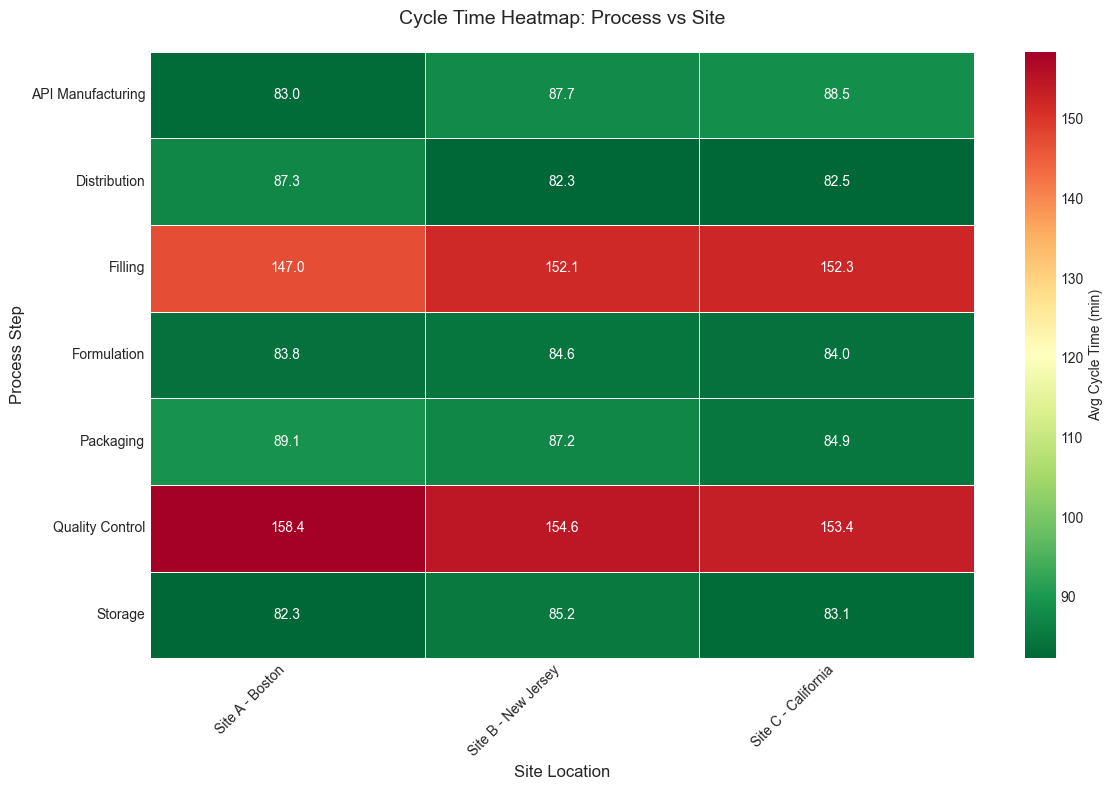

In [12]:
# Create heatmap of cycle times by process and site
pivot_table = df.pivot_table(
    values='cycle_time_minutes',
    index='process_step',
    columns='site_location',
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            linewidths=0.5, cbar_kws={'label': 'Avg Cycle Time (min)'})
plt.title('Cycle Time Heatmap: Process vs Site', fontsize=14, pad=20)
plt.xlabel('Site Location', fontsize=12)
plt.ylabel('Process Step', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/bottleneck_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Value Stream Mapping

In [13]:
vsm = lss.value_stream_mapping()
print("="*50)
print("VALUE STREAM MAPPING ANALYSIS")
print("="*50)
print("\nWaste Identification (Non-Value-Added Time):")
print(vsm)

VALUE STREAM MAPPING ANALYSIS

Waste Identification (Non-Value-Added Time):
                   cycle_time_minutes  wait_time_minutes  total_time  \
process_step                                                           
Filling                    150.489970          54.154216  204.644186   
Quality Control            155.508421          52.916654  208.425075   
Formulation                 84.116390          25.809243  109.925633   
Storage                     83.493475          25.451879  108.945354   
API Manufacturing           86.554386          26.155849  112.710236   
Distribution                84.098790          24.775769  108.874558   
Packaging                   87.064348          24.665076  111.729423   

                   value_added_ratio  waste_percentage  
process_step                                            
Filling                        0.735              26.5  
Quality Control                0.746              25.4  
Formulation                    0.765           

### Visualization 6: Value Stream Analysis

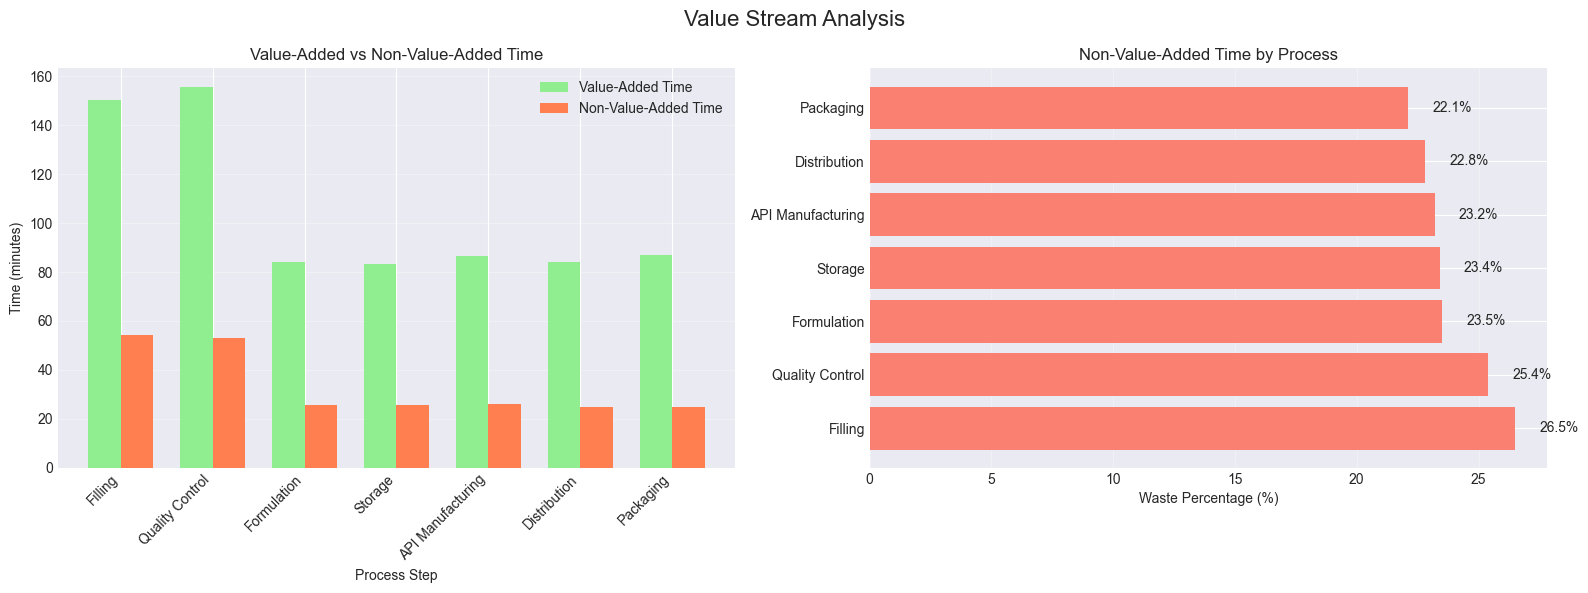

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Value Stream Analysis', fontsize=16)

# Value-Added vs Non-Value-Added Time
vsm_sorted = vsm.sort_values('waste_percentage', ascending=False)
x = range(len(vsm_sorted))
width = 0.35

axes[0].bar([i - width/2 for i in x], vsm_sorted['cycle_time_minutes'], 
           width, label='Value-Added Time', color='lightgreen')
axes[0].bar([i + width/2 for i in x], vsm_sorted['wait_time_minutes'], 
           width, label='Non-Value-Added Time', color='coral')
axes[0].set_xlabel('Process Step')
axes[0].set_ylabel('Time (minutes)')
axes[0].set_title('Value-Added vs Non-Value-Added Time')
axes[0].set_xticks(x)
axes[0].set_xticklabels(vsm_sorted.index, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Waste Percentage
axes[1].barh(range(len(vsm_sorted)), vsm_sorted['waste_percentage'], color='salmon')
axes[1].set_yticks(range(len(vsm_sorted)))
axes[1].set_yticklabels(vsm_sorted.index)
axes[1].set_xlabel('Waste Percentage (%)')
axes[1].set_title('Non-Value-Added Time by Process')
axes[1].grid(axis='x', alpha=0.3)

# Add percentage labels
for i, v in enumerate(vsm_sorted['waste_percentage']):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig('../outputs/value_stream_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
oee = lss.calculate_oee()
print("="*50)
print("OVERALL EQUIPMENT EFFECTIVENESS (OEE)")
print("="*50)
for key, value in oee.items():
    print(f"{key}: {value*100:.2f}%")
print(f"\nOEE Classification:")
if oee['OEE'] >= 0.85:
    print("World-Class Performance")
elif oee['OEE'] >= 0.60:
    print("Average Performance")
else:
    print("Below Average - Improvement Required")

OVERALL EQUIPMENT EFFECTIVENESS (OEE)
Availability: 74.77%
Performance: 93.87%
Quality: 87.35%
OEE: 61.31%

OEE Classification:
Average Performance


### Visualization 7: OEE Breakdown

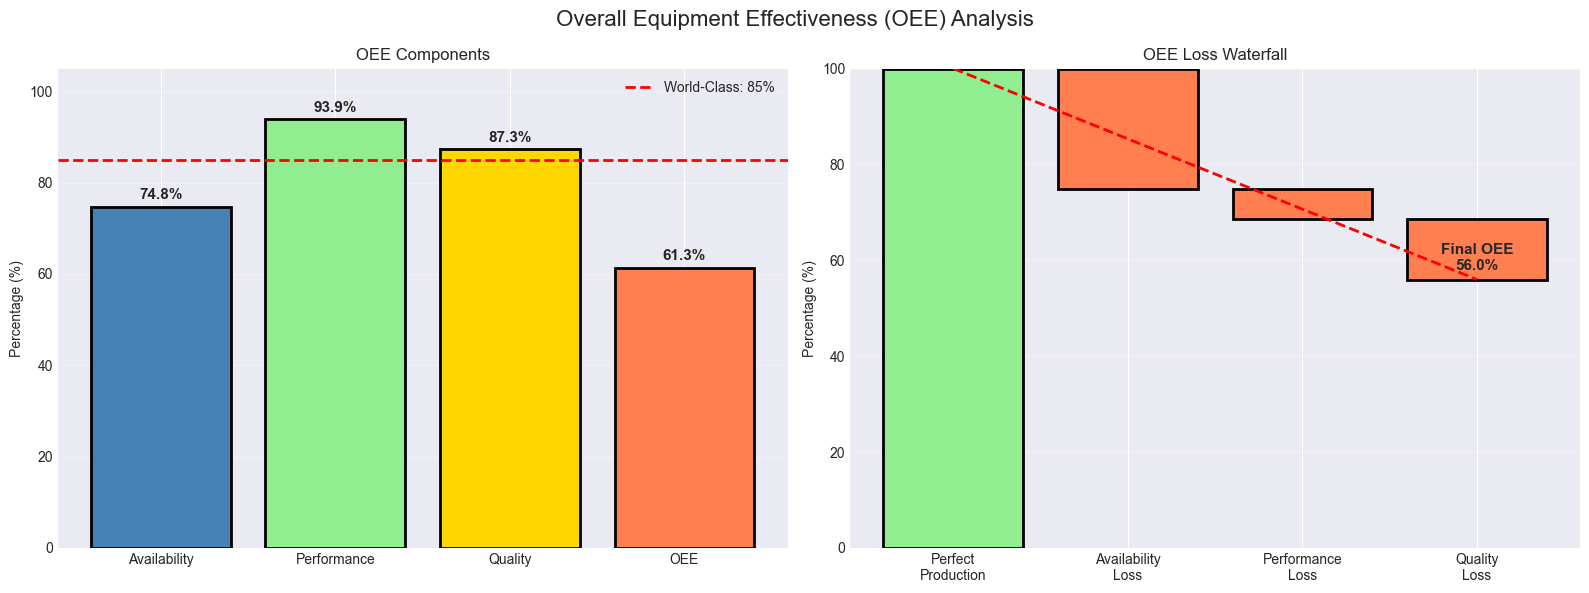

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Overall Equipment Effectiveness (OEE) Analysis', fontsize=16)

# OEE Components
components = ['Availability', 'Performance', 'Quality', 'OEE']
values = [oee['Availability']*100, oee['Performance']*100, 
          oee['Quality']*100, oee['OEE']*100]
colors = ['steelblue', 'lightgreen', 'gold', 'coral']

bars = axes[0].bar(components, values, color=colors, edgecolor='black', linewidth=2)
axes[0].axhline(y=85, color='red', linestyle='--', linewidth=2, label='World-Class: 85%')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('OEE Components')
axes[0].set_ylim(0, 105)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bar, value in zip(bars, values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{value:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# OEE Waterfall
waterfall_values = [100, -((1-oee['Availability'])*100), 
                   -((1-oee['Performance'])*100), 
                   -((1-oee['Quality'])*100)]
waterfall_labels = ['Perfect\nProduction', 'Availability\nLoss', 
                   'Performance\nLoss', 'Quality\nLoss']

cumulative = [100]
for val in waterfall_values[1:]:
    cumulative.append(cumulative[-1] + val)

axes[1].bar(range(len(waterfall_labels)), waterfall_values, 
           bottom=[0] + cumulative[:-1],
           color=['lightgreen', 'coral', 'coral', 'coral'],
           edgecolor='black', linewidth=2)
axes[1].plot([0, len(waterfall_labels)-1], [100, cumulative[-1]], 'r--', linewidth=2)
axes[1].set_xticks(range(len(waterfall_labels)))
axes[1].set_xticklabels(waterfall_labels)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('OEE Loss Waterfall')
axes[1].grid(axis='y', alpha=0.3)
axes[1].text(len(waterfall_labels)-1, cumulative[-1] + 2, 
            f'Final OEE\n{cumulative[-1]:.1f}%',
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/oee_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. AI Agent: Automated Analysis
### Pareto Analysis (80/20 Rule)

In [17]:
ai_agent = AIAnalysisAgent(df, config={"pareto_threshold": 0.8})

pareto_defects = ai_agent.pareto_analysis(group_by="process_step", metric="defect_count")
print("="*50)
print("PARETO ANALYSIS: DEFECT DISTRIBUTION")
print("="*50)
print(f"\nVital Few (80% impact): {pareto_defects['vital_few_count']} out of {pareto_defects['total_categories']} processes")
print(f"\nFocus Areas:")
print(pareto_defects['vital_few'])

PARETO ANALYSIS: DEFECT DISTRIBUTION

Vital Few (80% impact): 5 out of 7 processes

Focus Areas:
            category  value  percentage  cumulative_percentage
0        Formulation   6193       14.87                  14.87
1  API Manufacturing   6186       14.86                  29.73
2    Quality Control   6156       14.79                  44.52
3       Distribution   5926       14.23                  58.75
4          Packaging   5782       13.89                  72.64


### Visualization 8: Pareto Chart

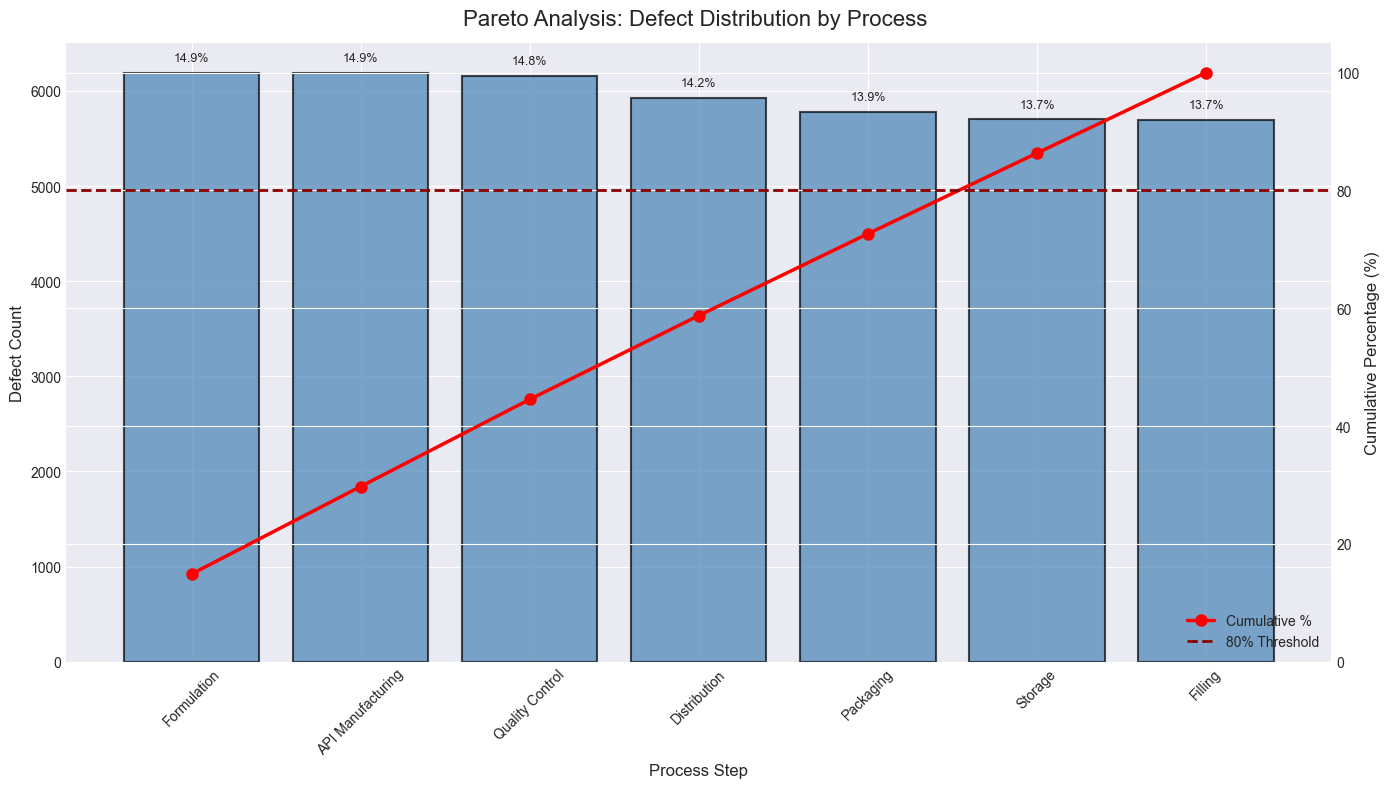

In [18]:
pareto_data = pareto_defects['pareto_data']

fig, ax1 = plt.subplots(figsize=(14, 8))
fig.suptitle('Pareto Analysis: Defect Distribution by Process', fontsize=16)

# Bar chart
ax1.bar(pareto_data['category'], pareto_data['value'], 
        color='steelblue', edgecolor='black', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Process Step', fontsize=12)
ax1.set_ylabel('Defect Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Line chart for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(pareto_data['category'], pareto_data['cumulative_percentage'], 
        color='red', marker='o', linewidth=2.5, markersize=8, label='Cumulative %')
ax2.axhline(y=80, color='darkred', linestyle='--', linewidth=2, label='80% Threshold')
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12)
ax2.set_ylim(0, 105)
ax2.legend(loc='lower right')

# Add percentage labels on bars
for i, (cat, val, pct) in enumerate(zip(pareto_data['category'], 
                                         pareto_data['value'], 
                                         pareto_data['percentage'])):
    ax1.text(i, val + max(pareto_data['value'])*0.02, 
            f'{pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/pareto_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
pareto_cost = ai_agent.pareto_analysis(group_by="product_line", metric="cost_usd")
print("="*50)
print("PARETO ANALYSIS: COST DISTRIBUTION")
print("="*50)
print(pareto_cost['pareto_data'])

PARETO ANALYSIS: COST DISTRIBUTION
         category         value  percentage  cumulative_percentage
0        Oncology  3.966294e+07       25.82                  25.82
1       Neurology  3.858264e+07       25.12                  50.94
2  Cardiovascular  3.785682e+07       24.65                  75.59
3      Immunology  3.749769e+07       24.41                 100.00


### Anomaly Detection

In [20]:
anomalies_cycle = ai_agent.detect_anomalies(metric="cycle_time_minutes", method="zscore", threshold=3.0)
print("="*50)
print("ANOMALY DETECTION: CYCLE TIME")
print("="*50)
print(f"Anomalies Detected: {anomalies_cycle['anomaly_count']}")
print(f"Percentage: {anomalies_cycle['anomaly_percentage']}%")
print(f"Method: Z-Score (threshold: {anomalies_cycle['threshold_used']} sigma)")

if anomalies_cycle['anomaly_count'] > 0:
    print("\nTop 5 Anomalous Records:")
    print(anomalies_cycle['anomalies'][['timestamp', 'process_step', 'cycle_time_minutes', 'cost_usd']].head())

ANOMALY DETECTION: CYCLE TIME
Anomalies Detected: 237
Percentage: 1.58%
Method: Z-Score (threshold: 3.0 sigma)

Top 5 Anomalous Records:
              timestamp       process_step  cycle_time_minutes      cost_usd
4   2024-01-01 04:00:00            Filling          398.451118   5621.429419
29  2024-01-02 05:00:00    Quality Control          405.719086   4371.836717
58  2024-01-03 10:00:00  API Manufacturing          504.398827  68840.520553
100 2024-01-05 04:00:00            Storage          413.504399   9169.386401
218 2024-01-10 02:00:00  API Manufacturing          438.042844  13532.962284


### Visualization 9: Anomaly Detection

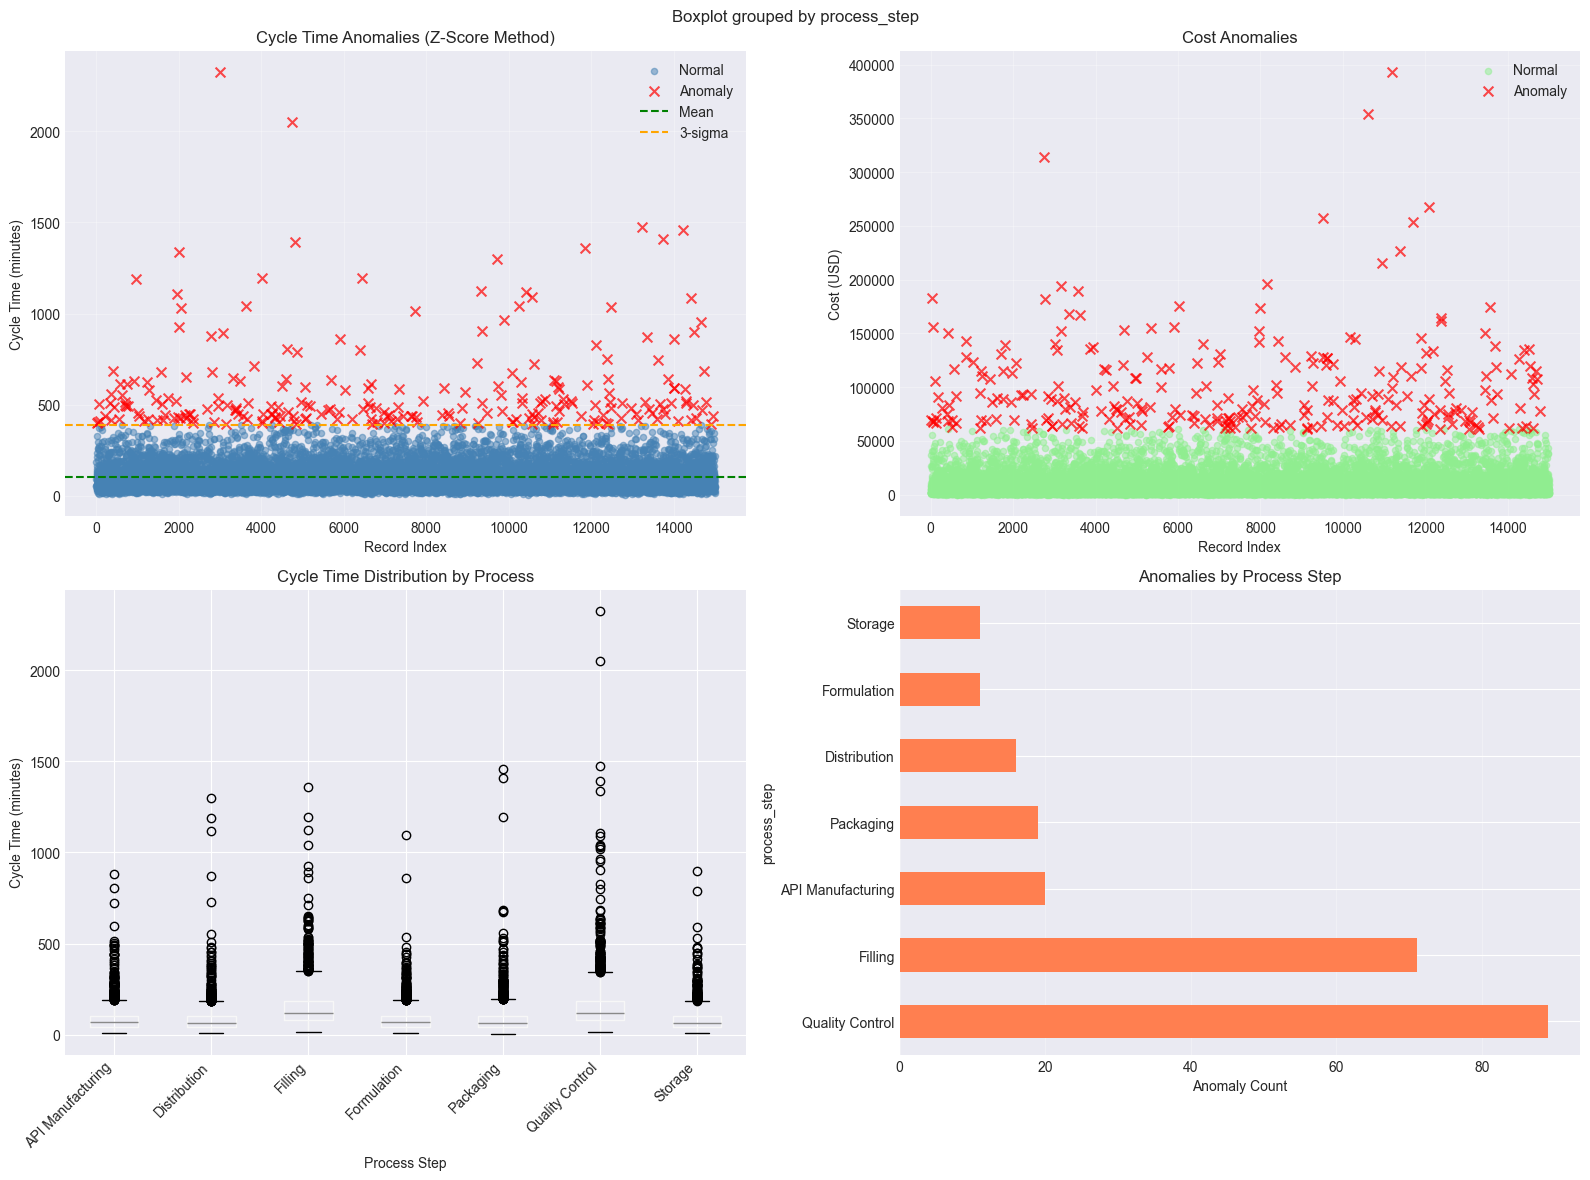

In [21]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Anomaly Detection Analysis', fontsize=16, y=0.995)

# Cycle Time with Anomalies
z_scores = np.abs(stats.zscore(df['cycle_time_minutes']))
normal = df[z_scores <= 3]
anomaly = df[z_scores > 3]

axes[0, 0].scatter(normal.index, normal['cycle_time_minutes'], 
                  alpha=0.5, s=20, color='steelblue', label='Normal')
axes[0, 0].scatter(anomaly.index, anomaly['cycle_time_minutes'], 
                  alpha=0.7, s=50, color='red', marker='x', label='Anomaly')
mean_val = df['cycle_time_minutes'].mean()
std_val = df['cycle_time_minutes'].std()
axes[0, 0].axhline(mean_val, color='green', linestyle='--', label='Mean')
axes[0, 0].axhline(mean_val + 3*std_val, color='orange', linestyle='--', label='3-sigma')
axes[0, 0].set_xlabel('Record Index')
axes[0, 0].set_ylabel('Cycle Time (minutes)')
axes[0, 0].set_title('Cycle Time Anomalies (Z-Score Method)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Cost Anomalies
z_scores_cost = np.abs(stats.zscore(df['cost_usd']))
normal_cost = df[z_scores_cost <= 3]
anomaly_cost = df[z_scores_cost > 3]

axes[0, 1].scatter(normal_cost.index, normal_cost['cost_usd'], 
                  alpha=0.5, s=20, color='lightgreen', label='Normal')
axes[0, 1].scatter(anomaly_cost.index, anomaly_cost['cost_usd'], 
                  alpha=0.7, s=50, color='red', marker='x', label='Anomaly')
axes[0, 1].set_xlabel('Record Index')
axes[0, 1].set_ylabel('Cost (USD)')
axes[0, 1].set_title('Cost Anomalies')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Box Plot - Cycle Time by Process
df.boxplot(column='cycle_time_minutes', by='process_step', ax=axes[1, 0])
axes[1, 0].set_title('Cycle Time Distribution by Process')
axes[1, 0].set_xlabel('Process Step')
axes[1, 0].set_ylabel('Cycle Time (minutes)')
axes[1, 0].tick_params(axis='x', rotation=45)
plt.sca(axes[1, 0])
plt.xticks(rotation=45, ha='right')

# Anomaly Count by Process
anomaly_by_process = anomaly.groupby('process_step').size().sort_values(ascending=False)
if len(anomaly_by_process) > 0:
    anomaly_by_process.plot(kind='barh', ax=axes[1, 1], color='coral')
    axes[1, 1].set_xlabel('Anomaly Count')
    axes[1, 1].set_title('Anomalies by Process Step')
    axes[1, 1].grid(axis='x', alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No anomalies detected', 
                   ha='center', va='center', transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.savefig('../outputs/anomaly_detection.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
anomalies_cost = ai_agent.detect_anomalies(metric="cost_usd", method="iqr")
print("="*50)
print("ANOMALY DETECTION: COST")
print("="*50)
print(f"Anomalies Detected: {anomalies_cost['anomaly_count']}")
print(f"Percentage: {anomalies_cost['anomaly_percentage']}%")
print(f"Method: IQR (Interquartile Range)")

ANOMALY DETECTION: COST
Anomalies Detected: 1409
Percentage: 9.39%
Method: IQR (Interquartile Range)


### Root Cause Analysis

In [23]:
root_causes = ai_agent.root_cause_analysis()
print("="*50)
print("ROOT CAUSE ANALYSIS")
print("="*50)

print("\n1. PROCESS-RELATED CAUSES:")
print(root_causes['process'])

print("\n2. PRODUCT LINE CAUSES:")
print(root_causes['product_line'])

print("\n3. ENVIRONMENTAL FACTORS:")
for key, value in root_causes['environmental'].items():
    print(f"  {key}: {value}")

print("\n4. EQUIPMENT-RELATED CAUSES (Top 5):")
print(root_causes['equipment'])

ROOT CAUSE ANALYSIS

1. PROCESS-RELATED CAUSES:
                       mean  count  defect_rate
process_step                                   
Formulation        6.412470    417       2674.0
Quality Control    6.409877    405       2596.0
API Manufacturing  6.344743    409       2595.0

2. PRODUCT LINE CAUSES:
                    mean  count  defect_rate
product_line                                
Oncology        6.593488   2150      14176.0
Immunology      5.481308    214       1173.0
Neurology       5.459016    183        999.0
Cardiovascular  5.469274    179        979.0

3. ENVIRONMENTAL FACTORS:
  temperature_correlation: -0.006
  humidity_correlation: 0.002

4. EQUIPMENT-RELATED CAUSES (Top 5):
              sum  count
equipment_id            
EQ-020        430     68
EQ-028        428     69
EQ-049        423     64
EQ-017        421     67
EQ-039        413     65


### Visualization 10: Root Cause Analysis

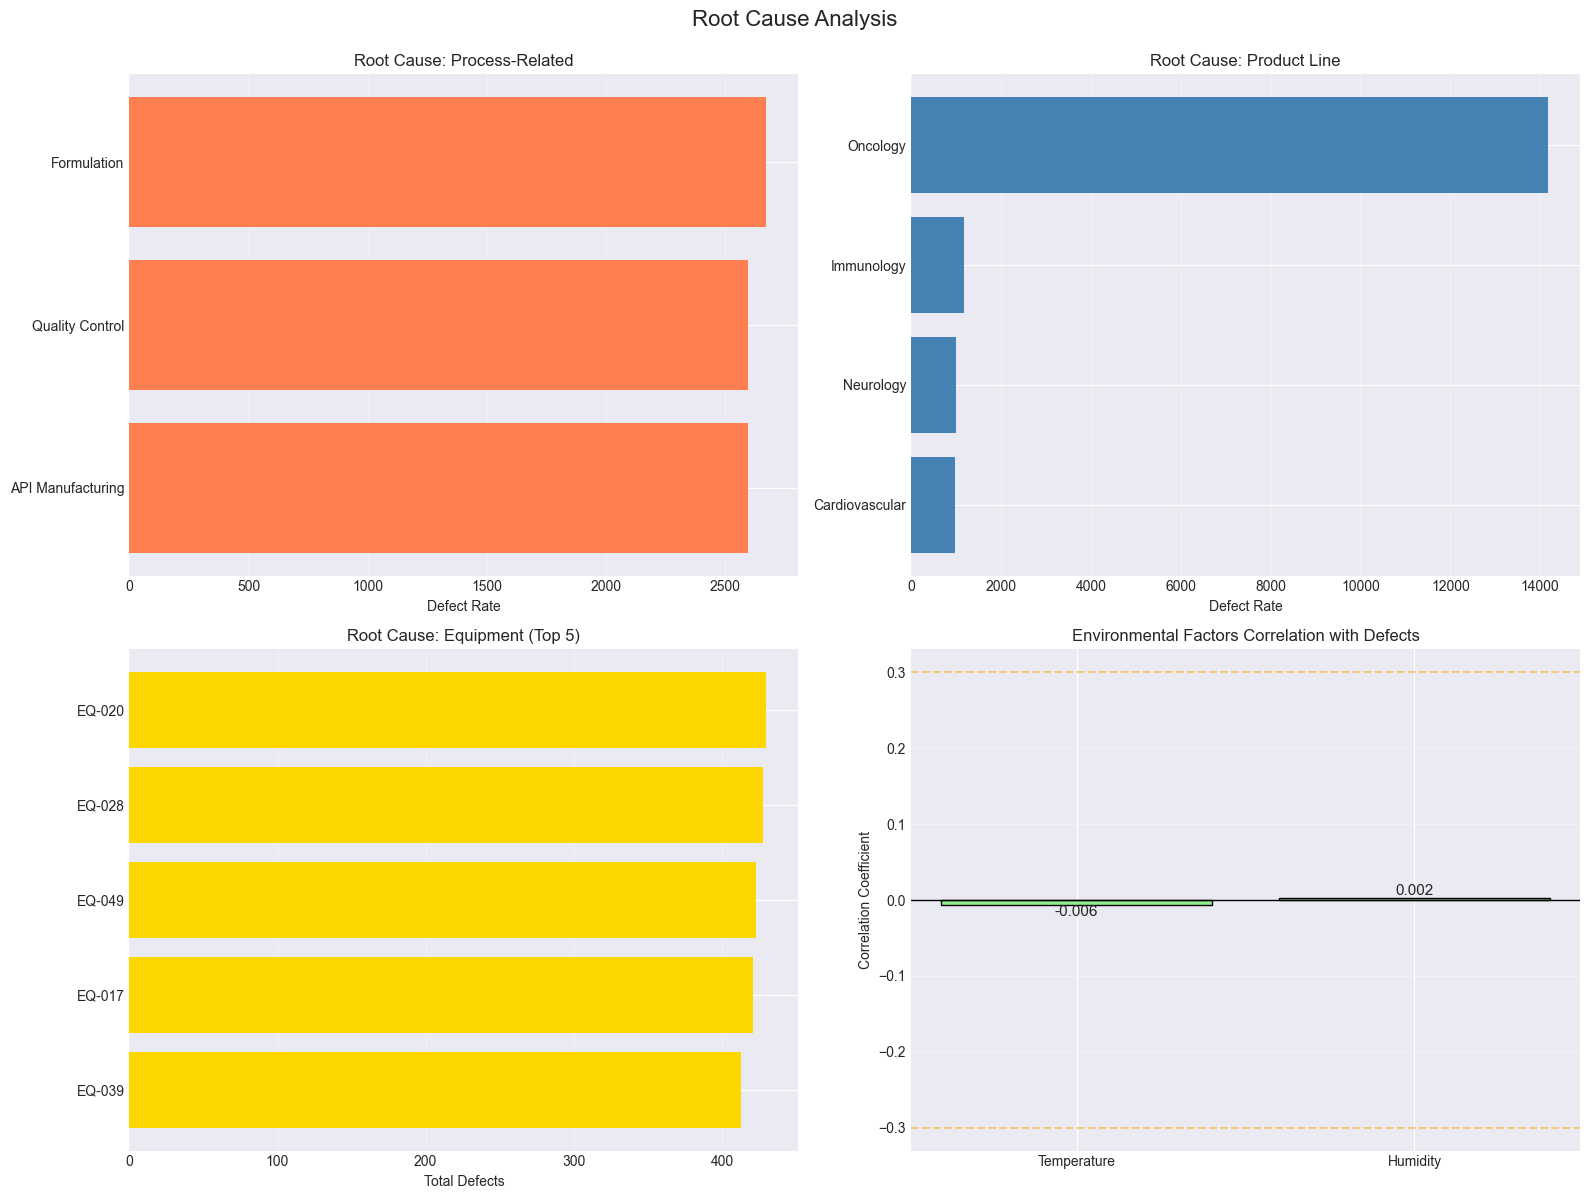

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Root Cause Analysis', fontsize=16, y=0.995)

# Process Root Causes
process_rc = root_causes['process']['defect_rate'].sort_values(ascending=True)
axes[0, 0].barh(range(len(process_rc)), process_rc.values, color='coral')
axes[0, 0].set_yticks(range(len(process_rc)))
axes[0, 0].set_yticklabels(process_rc.index)
axes[0, 0].set_xlabel('Defect Rate')
axes[0, 0].set_title('Root Cause: Process-Related')
axes[0, 0].grid(axis='x', alpha=0.3)

# Product Line Root Causes
product_rc = root_causes['product_line']['defect_rate'].sort_values(ascending=True)
axes[0, 1].barh(range(len(product_rc)), product_rc.values, color='steelblue')
axes[0, 1].set_yticks(range(len(product_rc)))
axes[0, 1].set_yticklabels(product_rc.index)
axes[0, 1].set_xlabel('Defect Rate')
axes[0, 1].set_title('Root Cause: Product Line')
axes[0, 1].grid(axis='x', alpha=0.3)

# Equipment Root Causes
if len(root_causes['equipment']) > 0:
    equipment_rc = root_causes['equipment']['sum'].sort_values(ascending=True)
    axes[1, 0].barh(range(len(equipment_rc)), equipment_rc.values, color='gold')
    axes[1, 0].set_yticks(range(len(equipment_rc)))
    axes[1, 0].set_yticklabels(equipment_rc.index)
    axes[1, 0].set_xlabel('Total Defects')
    axes[1, 0].set_title('Root Cause: Equipment (Top 5)')
    axes[1, 0].grid(axis='x', alpha=0.3)

# Environmental Correlation
env_factors = ['Temperature', 'Humidity']
correlations = [
    root_causes['environmental']['temperature_correlation'],
    root_causes['environmental']['humidity_correlation']
]
colors_corr = ['red' if abs(c) > 0.3 else 'lightgreen' for c in correlations]
bars = axes[1, 1].bar(env_factors, correlations, color=colors_corr, edgecolor='black')
axes[1, 1].axhline(y=0, color='black', linewidth=1)
axes[1, 1].axhline(y=0.3, color='orange', linestyle='--', alpha=0.5)
axes[1, 1].axhline(y=-0.3, color='orange', linestyle='--', alpha=0.5)
axes[1, 1].set_ylabel('Correlation Coefficient')
axes[1, 1].set_title('Environmental Factors Correlation with Defects')
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, correlations):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.3f}', ha='center', 
                   va='bottom' if height > 0 else 'top', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/root_cause_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Strategic Recommendations Generation

In [25]:
analysis_results = {
    'bottlenecks': bottlenecks,
    'pareto_quality': pareto_defects,
    'anomalies': anomalies_cycle,
    'cost_analysis': {'avg_cost': df['cost_usd'].mean()}
}

recommendations = ai_agent.generate_strategic_recommendations(analysis_results)
print("="*50)
print("PRIORITIZED STRATEGIC RECOMMENDATIONS")
print("="*50)
print(recommendations)

PRIORITIZED STRATEGIC RECOMMENDATIONS
   priority           category                                  issue  \
0      HIGH    Quality Control        High defect rate in Formulation   
1      HIGH    Quality Control  High defect rate in API Manufacturing   
2      HIGH    Quality Control    High defect rate in Quality Control   
3      HIGH    Quality Control       High defect rate in Distribution   
4      HIGH    Quality Control          High defect rate in Packaging   
5    MEDIUM     Cost Reduction        High operational costs detected   
6  CRITICAL  Anomaly Detection                 237 anomalies detected   

                    metric                                     recommendation  \
0   14.9% of total defects  Conduct FMEA and implement preventive controls...   
1   14.9% of total defects  Conduct FMEA and implement preventive controls...   
2   14.8% of total defects  Conduct FMEA and implement preventive controls...   
3   14.2% of total defects  Conduct FMEA and implemen

In [26]:
recommendations.to_excel('../outputs/strategic_recommendations.xlsx', index=False)
print("Recommendations exported to outputs/strategic_recommendations.xlsx")

Recommendations exported to outputs/strategic_recommendations.xlsx


### Visualization 11: Recommendations Dashboard

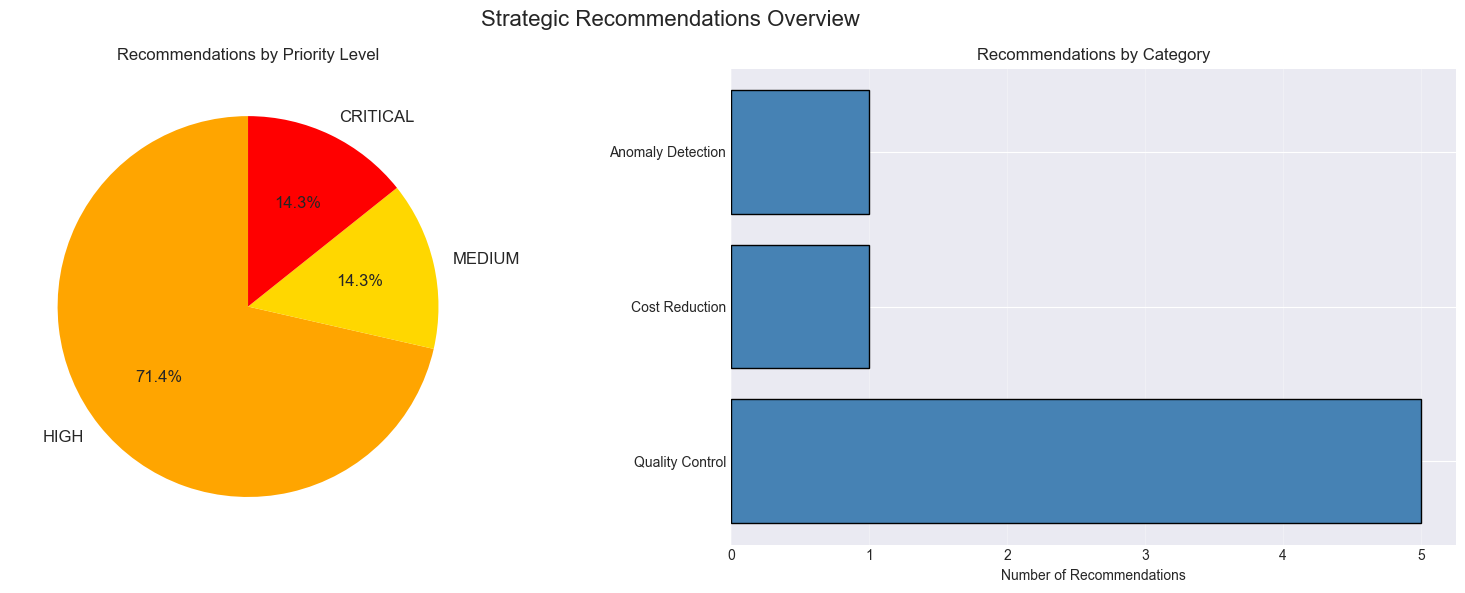

In [27]:
if len(recommendations) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Strategic Recommendations Overview', fontsize=16)
    
    # Priority Distribution
    priority_counts = recommendations['priority'].value_counts()
    colors_priority = {'CRITICAL': 'red', 'HIGH': 'orange', 'MEDIUM': 'gold', 'LOW': 'lightgreen'}
    pie_colors = [colors_priority.get(p, 'gray') for p in priority_counts.index]
    
    axes[0].pie(priority_counts.values, labels=priority_counts.index, autopct='%1.1f%%',
               colors=pie_colors, startangle=90, textprops={'fontsize': 12})
    axes[0].set_title('Recommendations by Priority Level')
    
    # Category Distribution
    category_counts = recommendations['category'].value_counts()
    axes[1].barh(range(len(category_counts)), category_counts.values, 
                color='steelblue', edgecolor='black')
    axes[1].set_yticks(range(len(category_counts)))
    axes[1].set_yticklabels(category_counts.index)
    axes[1].set_xlabel('Number of Recommendations')
    axes[1].set_title('Recommendations by Category')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/recommendations_overview.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No recommendations generated")

## 5. Executive Summary Generation

In [28]:
all_results = {
    'dpmo': dpmo_results,
    'capability': capability,
    'oee': oee,
    'bottlenecks': bottlenecks,
    'recommendations': recommendations
}

exec_summary = ai_agent.generate_executive_summary(all_results)
print("="*50)
print("EXECUTIVE SUMMARY")
print("="*50)
for key, value in exec_summary.items():
    print(f"{key.replace('_', ' ').title()}: {value}")

EXECUTIVE SUMMARY
Total Records Analyzed: 15000
Analysis Period: 2024-01-01 00:00:00 to 2025-09-16 23:00:00
Key Findings: []
Critical Issues: 1
High Priority Actions: 5
Estimated Savings Potential: $0


### Visualization 12: Executive KPI Dashboard

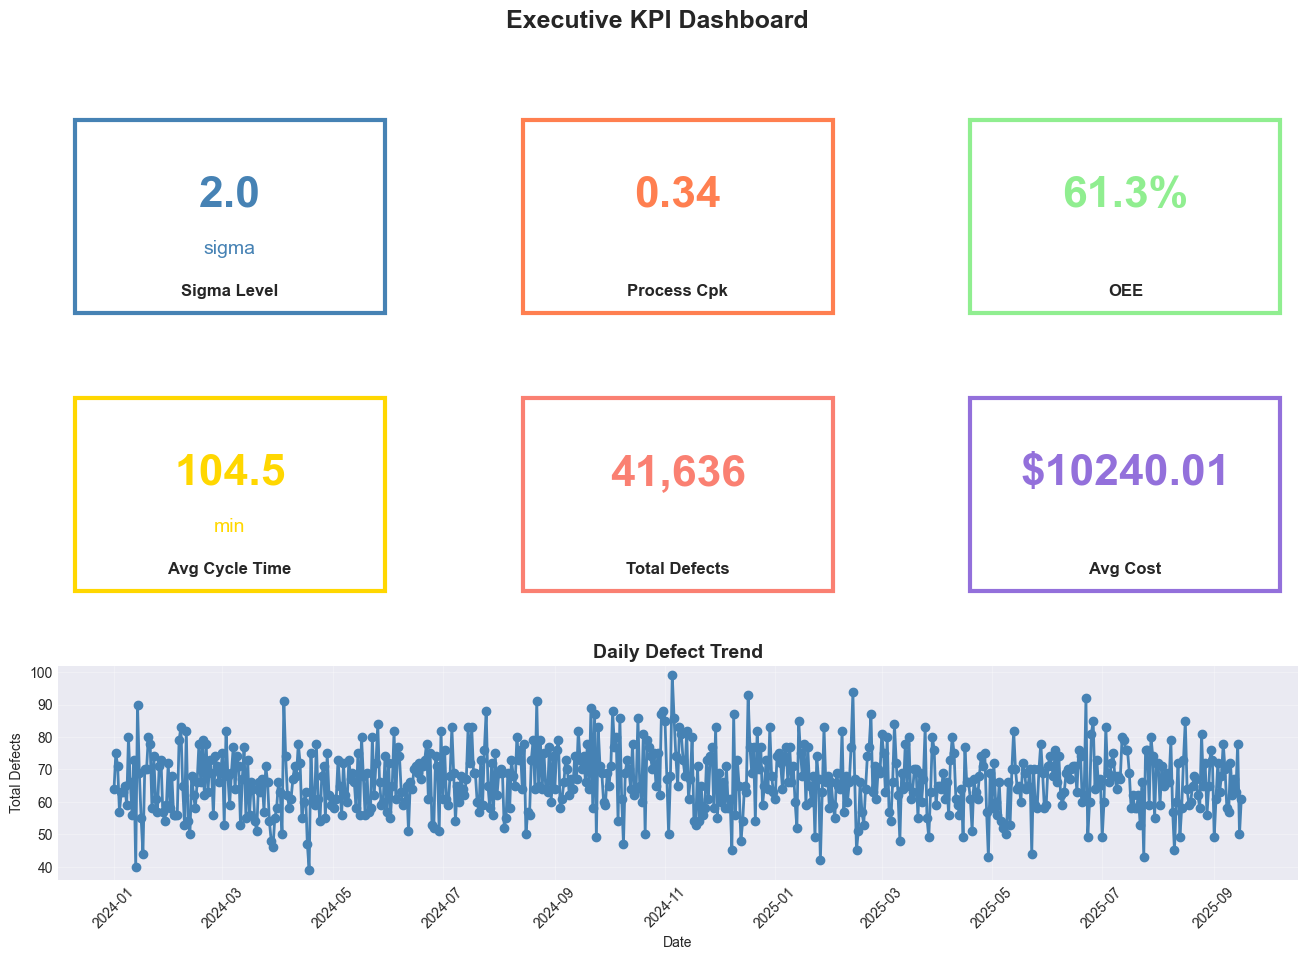

In [29]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
fig.suptitle('Executive KPI Dashboard', fontsize=18, fontweight='bold')

# KPI Cards
kpis = [
    ('Sigma Level', f"{dpmo_results['Sigma_Level']:.1f}", 'sigma', 'steelblue'),
    ('Process Cpk', f"{capability['Cpk']:.2f}", '', 'coral'),
    ('OEE', f"{oee['OEE']*100:.1f}%", '', 'lightgreen'),
    ('Avg Cycle Time', f"{df['cycle_time_minutes'].mean():.1f}", 'min', 'gold'),
    ('Total Defects', f"{df['defect_count'].sum():,.0f}", '', 'salmon'),
    ('Avg Cost', f"${df['cost_usd'].mean():.2f}", '', 'mediumpurple')
]

positions = [(0,0), (0,1), (0,2), (1,0), (1,1), (1,2)]

for (row, col), (title, value, unit, color) in zip(positions, kpis):
    ax = fig.add_subplot(gs[row, col])
    ax.text(0.5, 0.6, value, ha='center', va='center', 
           fontsize=32, fontweight='bold', color=color)
    ax.text(0.5, 0.35, unit, ha='center', va='center', 
           fontsize=14, color=color)
    ax.text(0.5, 0.15, title, ha='center', va='center', 
           fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    rect = plt.Rectangle((0.05, 0.05), 0.9, 0.9, 
                         fill=False, edgecolor=color, linewidth=3)
    ax.add_patch(rect)

# Summary Chart
ax_summary = fig.add_subplot(gs[2, :])
summary_data = df.groupby(df['timestamp'].dt.date)['defect_count'].sum()
ax_summary.plot(summary_data.index, summary_data.values, 
               color='steelblue', linewidth=2, marker='o')
ax_summary.set_title('Daily Defect Trend', fontsize=14, fontweight='bold')
ax_summary.set_xlabel('Date')
ax_summary.set_ylabel('Total Defects')
ax_summary.grid(alpha=0.3)
ax_summary.tick_params(axis='x', rotation=45)

plt.savefig('../outputs/executive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Performance Metrics & AI Governance

In [30]:
metrics_summary = pd.DataFrame([
    {'Metric': 'Records Processed', 'Value': f"{len(df):,}", 'Target': '15,000+', 'Status': 'PASS'},
    {'Metric': 'Sigma Level', 'Value': f"{dpmo_results['Sigma_Level']:.1f} sigma", 'Target': '6 sigma', 'Status': 'REVIEW'},
    {'Metric': 'Process Capability (Cpk)', 'Value': f"{capability['Cpk']:.2f}", 'Target': '>=1.33', 'Status': 'PASS' if capability['Cpk'] >= 1.33 else 'FAIL'},
    {'Metric': 'OEE', 'Value': f"{oee['OEE']*100:.1f}%", 'Target': '>=85%', 'Status': 'PASS' if oee['OEE'] >= 0.85 else 'REVIEW'},
    {'Metric': 'Bottlenecks Identified', 'Value': str(len(bottlenecks)), 'Target': 'N/A', 'Status': 'PASS'},
    {'Metric': 'Anomalies Detected', 'Value': str(anomalies_cycle['anomaly_count']), 'Target': '<2%', 'Status': 'PASS' if anomalies_cycle['anomaly_percentage'] < 2 else 'REVIEW'},
    {'Metric': 'Strategic Recommendations', 'Value': str(len(recommendations)), 'Target': '4+', 'Status': 'PASS'}
])

print("="*70)
print("AI GOVERNANCE: PERFORMANCE METRICS DASHBOARD")
print("="*70)
print(metrics_summary)

AI GOVERNANCE: PERFORMANCE METRICS DASHBOARD
                      Metric      Value   Target  Status
0          Records Processed     15,000  15,000+    PASS
1                Sigma Level  2.0 sigma  6 sigma  REVIEW
2   Process Capability (Cpk)       0.34   >=1.33    FAIL
3                        OEE      61.3%    >=85%  REVIEW
4     Bottlenecks Identified          0      N/A    PASS
5         Anomalies Detected        237      <2%    PASS
6  Strategic Recommendations          7       4+    PASS


In [31]:
metrics_summary.to_excel('../outputs/ai_governance_metrics.xlsx', index=False)
print("AI Governance metrics exported")

AI Governance metrics exported


## 7. Final Exports & Documentation

In [32]:
# Export comprehensive analysis report
with pd.ExcelWriter('../outputs/comprehensive_analysis_report.xlsx', engine='openpyxl') as writer:
    df.describe().to_excel(writer, sheet_name='Data Summary')
    if len(bottlenecks) > 0:
        bottlenecks.to_excel(writer, sheet_name='Bottlenecks')
    vsm.to_excel(writer, sheet_name='Value Stream Map')
    pareto_defects['pareto_data'].to_excel(writer, sheet_name='Pareto Analysis', index=False)
    if len(recommendations) > 0:
        recommendations.to_excel(writer, sheet_name='Recommendations', index=False)
    metrics_summary.to_excel(writer, sheet_name='Performance Metrics', index=False)

print("Comprehensive analysis report exported")
print("All visualizations saved to outputs/")
print("\n" + "="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

Comprehensive analysis report exported
All visualizations saved to outputs/

PROJECT COMPLETED SUCCESSFULLY


In [33]:
# Print file summary
import os
output_files = [f for f in os.listdir('../outputs') if not f.startswith('.')]
print("\nGenerated Output Files:")
for i, file in enumerate(sorted(output_files), 1):
    print(f"  {i}. {file}")


Generated Output Files:
  1. ai_governance_metrics.xlsx
  2. anomaly_detection.png
  3. bottleneck_heatmap.html
  4. bottleneck_heatmap.png
  5. comprehensive_analysis_report.xlsx
  6. cost_analysis.html
  7. executive_dashboard.png
  8. metric_distributions.png
  9. oee_analysis.png
  10. pareto_chart.html
  11. pareto_chart.png
  12. process_analysis.png
  13. process_capability.png
  14. quality_control_chart.html
  15. recommendations_overview.png
  16. root_cause_analysis.png
  17. site_comparison.png
  18. strategic_recommendations.xlsx
  19. trend_analysis.html
  20. value_stream_analysis.png
